In [1]:
# Import standard libraries
import sys

sys.path.append("..")

import phcpy  # Homotopy continuation package
from phcpy.dimension import get_core_count # For getting number of CPU cores
from phcpy.solver import solve # For solving polynomial systems
from phcpy.solutions import filter_real # For filtering real solutions

from sympy.plotting import plot_implicit # For plotting implicit curves
import matplotlib.pyplot as plt # For plotting

# Import our modules
from src.model import *
from src.nnexpansion import *
from src.utils import *

PHCv2.4.90 released 2024-03-20 works!


Generating training data with sin(x) decision boundary...
Training data shape: torch.Size([2000, 2])
Labels shape: torch.Size([2000])
Class distribution: tensor([1019,  981])


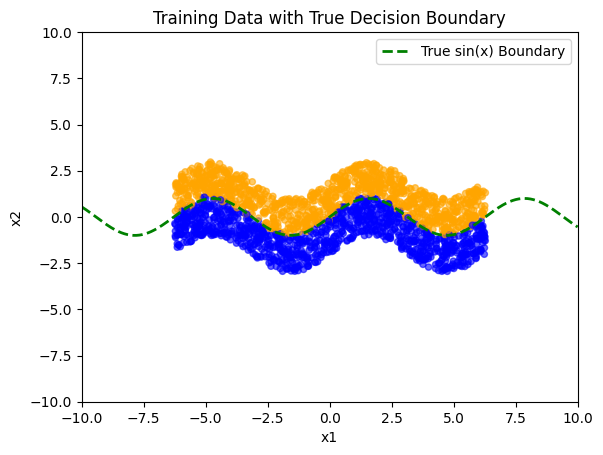

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Generate training data
print("Generating training data with sin(x) decision boundary...")
X_train, y_train = generate_sin_boundary_data(n_samples=2000, noise_level=0.1)

print(f"Training data shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")
print(f"Class distribution: {torch.bincount(y_train.long())}")

X_train_np = X_train.numpy()
y_train_np = y_train.numpy()

colors = ["blue" if label == 0 else "orange" for label in y_train_np]
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=colors, alpha=0.6, s=20)

x_range = (-10, 10)
y_range = (-10, 10)

# Plot true sin(x) boundary
x_true = np.linspace(x_range[0], x_range[1], 1000)
y_true = np.sin(x_true)
plt.plot(x_true, y_true, "g--", linewidth=2, label="True sin(x) Boundary")
plt.xlim(x_range)
plt.ylim(y_range)
plt.title("Training Data with True Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [3]:
# Create polynomial network
model = PolynomialNetwork(
    input_dim=2,
    output_dim=2,  # Binary classification with 2 outputs
    hidden_dims=[8, 6],
    polynomial_degree=3,
)

print(f"\nModel architecture:")
print(f"Input dim: {model.input_dim}")
print(f"Hidden dims: {model.hidden_dims}")
print(f"Output dim: {model.output_dim}")
print(f"Polynomial degree: {model.polynomial_degree}")

# Train the model
print("\nTraining the model...")
losses, accuracies = train_model(model, X_train, y_train, epochs=3000, lr=1e-3)


Model architecture:
Input dim: 2
Hidden dims: [8, 6]
Output dim: 2
Polynomial degree: 3

Training the model...
Epoch [500/3000], Loss: 0.2294, Accuracy: 0.8985
Epoch [1000/3000], Loss: 0.0513, Accuracy: 0.9795
Epoch [1500/3000], Loss: 0.0416, Accuracy: 0.9840
Epoch [2000/3000], Loss: 0.0384, Accuracy: 0.9855
Epoch [2500/3000], Loss: 0.0356, Accuracy: 0.9865
Epoch [3000/3000], Loss: 0.0323, Accuracy: 0.9865


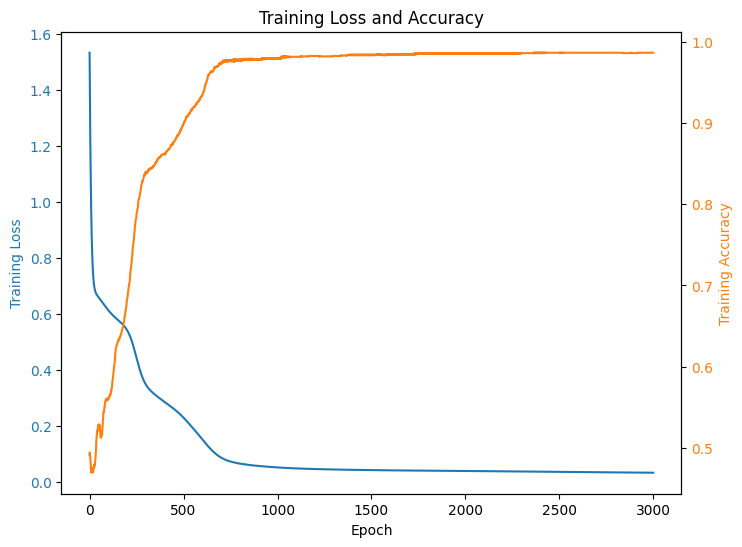

In [4]:
# Plot training loss and accuracies on a single plot with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot loss on left y-axis
color1 = 'tab:blue'
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color = color1)
ax1.plot(losses, label="Loss", color = color1)
ax1.tick_params(axis="y", labelcolor = color1)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel("Training Accuracy", color = color2)
ax2.plot(accuracies, label="Accuracy", color = color2)
ax2.tick_params(axis="y", labelcolor = color2)

# Add title and display the plot
plt.title("Training Loss and Accuracy")
plt.show()


Visualizing decision boundary...


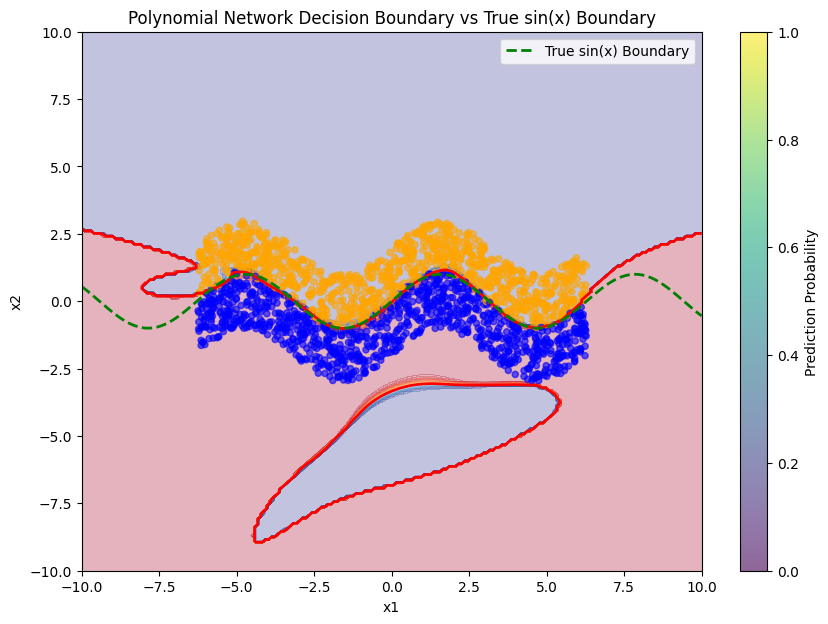

In [5]:
# Visualize decision boundary
print("\nVisualizing decision boundary...")
visualize_decision_boundary(
    model, X_train, y_train, x_range=x_range, y_range=y_range
)

In [6]:
# Monomial Expansion
monoms, C = polynomial_nn_expansion(model)
print("Number of monomials: ", len(monoms))
print("Shape of Coefficient matrix:", C.shape)

print("Monomials:", monoms)

Input symbols: (x0, x1)
Layer 0 weight: (8, 2)
Layer 0 bias: (8, 1)
Layer 0 activation: (4,)
Layer 1 weight: (6, 8)
Layer 1 bias: (6, 1)
Layer 1 activation: (4,)
Layer 2 weight: (2, 6)
Layer 2 bias: (2, 1)
Layer 2 activation: None
Polynomial expansion took 0.8731 seconds.
Number of monomials:  55
Shape of Coefficient matrix: (2, 55)
Monomials: [(0, 0), (0, 1), (1, 0), (0, 2), (1, 1), (2, 0), (0, 3), (1, 2), (2, 1), (3, 0), (0, 4), (1, 3), (2, 2), (3, 1), (4, 0), (0, 5), (1, 4), (2, 3), (3, 2), (4, 1), (5, 0), (0, 6), (1, 5), (2, 4), (3, 3), (4, 2), (5, 1), (6, 0), (0, 7), (1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1), (7, 0), (0, 8), (1, 7), (2, 6), (3, 5), (4, 4), (5, 3), (6, 2), (7, 1), (8, 0), (0, 9), (1, 8), (2, 7), (3, 6), (4, 5), (5, 4), (6, 3), (7, 2), (8, 1), (9, 0)]


In [7]:
# Fix a center point and check its class
x_center = torch.tensor([0.0, -4.0])
gold_class = torch.argmax(model(x_center))
print(f"Class at x_center {x_center.numpy().tolist()}: {gold_class.item()}")

coeff_diff = compute_class_differences(C, gold_class)
print(f"Shape of coefficient differences: {coeff_diff.shape}")

Class at x_center [0.0, -4.0]: 1
Shape of coefficient differences: (1, 55)


In [8]:
poly_decision = polynomial_system_to_phcpy(coeff_diff, monoms)

In [ ]:
x0, x1 = sp.symbols('x0 x1')
p0 = eval(poly_decision[0][:-1])

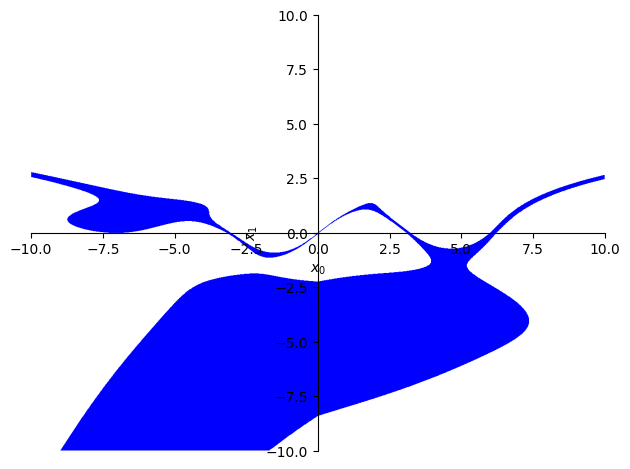

In [12]:
eq = sp.Eq(p0, 0)
plot_implicit(eq, (x0, x_range[0], x_range[1]), (x1, y_range[0], y_range[1]))